Autograd
This is what makes is what makes PyTorch flexible and fast for building machine learning projects. Allows for the rapid and easy computation of gradients or partial derivatives over a complex computation. Operation is central to backpropagation based neural network learning. 

Power of autograd comes from the fact it traces your computation dynamically a runtime, meaning if model has decision branches or loops whose strength are not know until runtime, the computation will still be traced correctly, and you'll get the correct gradients to drive learing. Combined with model built in Python, offer more than frameworks rely on static analysis of more rigidly structured model.

Idea: Loss function is how far from ideal answer, take partial derivatives of loss function to adjust learning weights

What do we need Autograd for:
Machine learning model is a function with I/O. Treat inputs as an i deminsional vectors with elements xi. Express model M as y=M(x). Mostly be discussing autograd in the context of training, our output of interest will be the model's loss. Loss function L(y)=L(m(x)) is a single valued scalar function of model output. 

Since we'll mostly be discussing autograd in the context of training, our output of interest will be the mode's loss. Loss function L(y)=L(m(x)) is a single-valued scalar function of the model's output. The function expresses how far off our model's prediction was from a particular input's ideal output. 

Training, minimize loss, adjusting learning weights. Adjustable parameters of the function. Such that loss is zero for all inputs. Real world, iterative process of nudging the learning weights until we see tolerable loss.

How do we decide how far and in which direction to nudge weights. Want to minimize loss, means making its derivative respect to input derivativeloss/dx=0;

Loss not directly derived from input, but function of models output. Since number of local derivatives go up exponentially, so does complexity in computing the,. Autograd comes in by tracking history of every computation, every compted tensor in PyToch model carries history of its input tensors and funcitons used to create it. Combined with Pytorch function acting on tensors are built in, speeds up need for learning. 

In [2]:
%matplotlib inline

In [3]:
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math

Next we'll create an input tensor full of evenly spaced values on interval 0 to 2pi and specify requires_grad=True. (torhc.linspace) accepts an optional requires_grad option. Setting this flag means that in every computation that follows, autograd will be accumulating the history of the computation in the output tensors of that computation. 

In [4]:
a=torch.linspace(0., 2*math.pi, 25, requires_grad=True)
print(a)

tensor([0.0000, 0.2618, 0.5236, 0.7854, 1.0472, 1.3090, 1.5708, 1.8326, 2.0944,
        2.3562, 2.6180, 2.8798, 3.1416, 3.4034, 3.6652, 3.9270, 4.1888, 4.4506,
        4.7124, 4.9742, 5.2360, 5.4978, 5.7596, 6.0214, 6.2832],
       requires_grad=True)


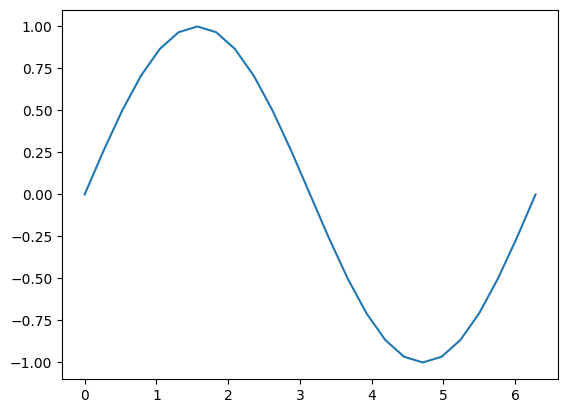

In [5]:
b=torch.sin(a)
plt.plot(a.detach(), b.detach())

In [6]:
print(b)

tensor([ 0.0000e+00,  2.5882e-01,  5.0000e-01,  7.0711e-01,  8.6603e-01,
         9.6593e-01,  1.0000e+00,  9.6593e-01,  8.6603e-01,  7.0711e-01,
         5.0000e-01,  2.5882e-01, -8.7423e-08, -2.5882e-01, -5.0000e-01,
        -7.0711e-01, -8.6603e-01, -9.6593e-01, -1.0000e+00, -9.6593e-01,
        -8.6603e-01, -7.0711e-01, -5.0000e-01, -2.5882e-01,  1.7485e-07],
       grad_fn=<SinBackward0>)


This grad_fn gives us a hint that when we execute the backpropogation step and compute graidnets, we'll need to compute derivative of sin(x) for ths tensor output.

More computations:

In [7]:
c=2*b
print(c)

d=c+1
print(d)

tensor([ 0.0000e+00,  5.1764e-01,  1.0000e+00,  1.4142e+00,  1.7321e+00,
         1.9319e+00,  2.0000e+00,  1.9319e+00,  1.7321e+00,  1.4142e+00,
         1.0000e+00,  5.1764e-01, -1.7485e-07, -5.1764e-01, -1.0000e+00,
        -1.4142e+00, -1.7321e+00, -1.9319e+00, -2.0000e+00, -1.9319e+00,
        -1.7321e+00, -1.4142e+00, -1.0000e+00, -5.1764e-01,  3.4969e-07],
       grad_fn=<MulBackward0>)
tensor([ 1.0000e+00,  1.5176e+00,  2.0000e+00,  2.4142e+00,  2.7321e+00,
         2.9319e+00,  3.0000e+00,  2.9319e+00,  2.7321e+00,  2.4142e+00,
         2.0000e+00,  1.5176e+00,  1.0000e+00,  4.8236e-01, -3.5763e-07,
        -4.1421e-01, -7.3205e-01, -9.3185e-01, -1.0000e+00, -9.3185e-01,
        -7.3205e-01, -4.1421e-01,  4.7684e-07,  4.8236e-01,  1.0000e+00],
       grad_fn=<AddBackward0>)


Finally, let's compute a single-element output. When you call .backward() on a tensor with no arguments, it expects the calling tensor to contain only a single element, as is the case when computing a loss function

In [8]:
out=d.sum()
print(out)

tensor(25., grad_fn=<SumBackward0>)


Each grad_fn stored our tensors allowed you to walk the computation all the way to its inputs with next_functions property. Drilling on d shows us graident functions for all prioir tensors. a.grad_fn is reported as None, meaning it's function input. 

In [9]:
print('d: ')
print(d.grad_fn)
print(d.grad_fn.next_functions)
print(d.grad_fn.next_functions[0][0].next_functions)
print(d.grad_fn.next_functions[0][0].next_functions[0][0].next_functions)
print(d.grad_fn.next_functions[0][0].next_functions[0][0].next_functions[0][0].next_functions)
print('\nc: ')
print(c.grad_fn)
print('\nb: ')
print(b.grad_fn)
print('\na: ')
print(a.grad_fn)

d: 
((<MulBackward0 object at 0x000002CE90E7FFD0>, 0), (None, 0))
((<SinBackward0 object at 0x000002CE90E7FFD0>, 0), (None, 0))
((<AccumulateGrad object at 0x000002CE90E2C130>, 0),)
()

c: 

b: 

a: 
None


With all machinery in place, how do we get derivatives out? You call the backward() method on the output, and check the input's grad property to inspect the gradients:

tensor([ 2.0000e+00,  1.9319e+00,  1.7321e+00,  1.4142e+00,  1.0000e+00,
         5.1764e-01, -8.7423e-08, -5.1764e-01, -1.0000e+00, -1.4142e+00,
        -1.7321e+00, -1.9319e+00, -2.0000e+00, -1.9319e+00, -1.7321e+00,
        -1.4142e+00, -1.0000e+00, -5.1764e-01,  2.3850e-08,  5.1764e-01,
         1.0000e+00,  1.4142e+00,  1.7321e+00,  1.9319e+00,  2.0000e+00])


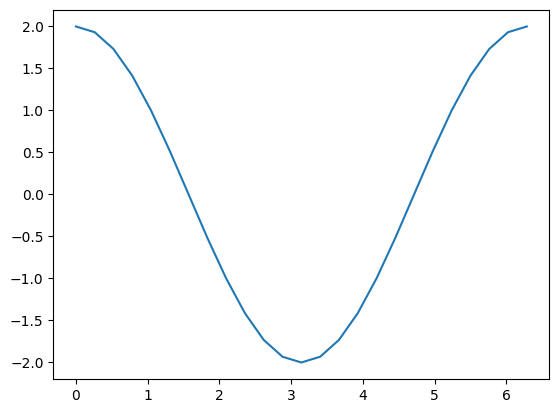

In [10]:
out.backward()
print(a.grad)
plt.plot(a.detach(), a.grad.detach())

we get this gradient since the graident of sin is cosine. we also multiplied it by 2 so we multiply cos(x) by 2. adding 1 does nothing to the graident

Autograd in Training
We've had a brief look at how autograd works, but how does it look when it's used for its intended purpose? Let's define a small model and examine how it changes after a single trianing batch. First define a few constants, our model, and some stand-ins for inputs and outputs. 

In [17]:
BATCH_SIZE = 16
DIM_IN=1000
HIDDEN_SIZE=100
DIM_OUT=10

class TinyModel(torch.nn.Module):

    def __init__(self):
        super(TinyModel, self).__init__()
        self.layer1=torch.nn.Linear(1000, 100)
        self.relu=torch.nn.ReLU()
        self.layer2=torch.nn.Linear(100, 10)

    def forward(self, x):
        x=self.layer1(x)
        x=self.relu(x)
        x=self.layer2(x)
        return x
some_input=torch.randn(BATCH_SIZE, DIM_IN, requires_grad=False)
ideal_output=torch.randn(BATCH_SIZE, DIM_OUT, requires_grad=True)

model=TinyModel()

Never specify Requires_grad=True for the model's layers. Within a subclass of torch.nn.module, it's assumend that we want to track gradients on the layers' weights for learning.

If we look at the layers of the model, we can examine the values of the weights, and verify that no gradients have been computed yet:

In [18]:
print(model.layer2.weight[0][0:10])
print(model.layer2.weight.grad)

tensor([ 0.0750, -0.0792, -0.0325, -0.0203,  0.0569, -0.0538,  0.0071,  0.0764,
         0.0919, -0.0422], grad_fn=<SliceBackward0>)
None


Look at the changes when run through one training batch. For a loss function, we'll use square of euclidian distance between prediction and ideal_output. use basic stochastic gradient descent optimizer

In [19]:
optimizer=torch.optim.SGD(model.parameters(), lr=0.001)

prediction=model(some_input)

loss=(ideal_output-prediction).pow(2).sum()
print(loss)

tensor(191.4105, grad_fn=<SumBackward0>)


Now we call loss.backward()

In [20]:
loss.backward()
print(model.layer2.weight[0][0:10])
print(model.layer2.weight.grad[0][0:10])

tensor([ 0.0750, -0.0792, -0.0325, -0.0203,  0.0569, -0.0538,  0.0071,  0.0764,
         0.0919, -0.0422], grad_fn=<SliceBackward0>)
tensor([ 3.9359, -1.4568,  3.3394,  3.2201,  2.4493,  6.0011, -0.6256,  2.0376,
        -2.0801,  4.3117])


Gradients have been computed for each learning weight, but the weights remaind unchanged. We haven't run the optimizer yet. Optimizer responsible for updating model weights based on the computed gradients.

In [21]:
optimizer.step()
print(model.layer2.weight[0][0:10])
print(model.layer2.weight.grad[0][0:10])

tensor([ 0.0710, -0.0778, -0.0358, -0.0235,  0.0544, -0.0598,  0.0077,  0.0744,
         0.0940, -0.0465], grad_fn=<SliceBackward0>)
tensor([ 3.9359, -1.4568,  3.3394,  3.2201,  2.4493,  6.0011, -0.6256,  2.0376,
        -2.0801,  4.3117])


layer2's weights hvae changed. This is how the model learns.

One important thing about the process: After calling optimizer.step(), you need to call optimizer.zero_grad(), or else every time you run loss.backward(), the gradients on the learning weights accumulate:

In [22]:
print(model.layer2.weight.grad[0][0:10])

for i in range(0,5):
    prediction=model(some_input)
    loss=(ideal_output-prediction).pow(2).sum()
    loss.backward()

print(model.layer2.weight.grad[0][0:10])

optimizer.zero_grad()

print(model.layer2.weight.grad[0][0:10])

tensor([ 3.9359, -1.4568,  3.3394,  3.2201,  2.4493,  6.0011, -0.6256,  2.0376,
        -2.0801,  4.3117])
tensor([  4.7966,  13.0400,  21.2343,  20.4490,   9.4815,  17.3982,  -4.1652,
          0.2265, -14.1454,  21.8792])


TypeError: 'NoneType' object is not subscriptable

After runinng the cell, loss.backward() multiple times, magnitudes of most of graidents much larger. Failing to zero gradients will cause them to blow up in thi smanner, causing incorrect and upredictable results. 

Turning Autograd Off and On
There are situations where you will need fine-grained control over whether autograd is enabled. Multiple ways to do it.

Simplest way is to change the requires_grad flag on a tensor directly. 

In [23]:
a=torch.ones(2,3, requires_grad=True)
print(a)

b1=2*a
print(b1)

a.requires_grad=False
b2=2*a
print(b2)

tensor([[1., 1., 1.],
        [1., 1., 1.]], requires_grad=True)
tensor([[2., 2., 2.],
        [2., 2., 2.]], grad_fn=<MulBackward0>)
tensor([[2., 2., 2.],
        [2., 2., 2.]])


see that b1 has a grad_fn, traced computation history, which is what we expect, since it was derived from a tensor a that has autograd turned on. When we turn off autograd with a.requires_grad=False, computation history is no longer tracker, as we see when we compute b2

In [24]:
a=torch.ones(2,3, requires_grad=True) * 2
b=torch.ones(2,3, requires_grad=True) * 3

c1=a+b
print(c1)

with torch.no_grad():
    c2=a+b
print(c2)

c3=a*b
print(c3)

tensor([[5., 5., 5.],
        [5., 5., 5.]], grad_fn=<AddBackward0>)
tensor([[5., 5., 5.],
        [5., 5., 5.]])
tensor([[6., 6., 6.],
        [6., 6., 6.]], grad_fn=<MulBackward0>)


torch.no_grad can be used as function or method decorator:

In [25]:
def add_tensors(x,y):
    return x+y
@torch.no_grad()
def add_tensors2(x,y):
    return x+y

a=torch.ones(2,3, requires_grad=True) * 2
b=torch.ones(2,3, requires_grad=True) * 3

c1=add_tensors(a,b)
print(c1)

c2=add_tensors2(a,b)
print(c2)


tensor([[5., 5., 5.],
        [5., 5., 5.]], grad_fn=<AddBackward0>)
tensor([[5., 5., 5.],
        [5., 5., 5.]])


There's a corresponding context manager, torch.enable_grad(), for turning autograd on when it isn't already. Iy may also be used as a decorator.

Finally may have tensor that has gradient tracker but want a copy that doesn't/ For this, we have Tensor object's detach() method. It creates a copy of the tensor that is detached from computation history:

In [26]:
x=torch.rand(5, requires_grad=True)
y=x.detach()

print(x)
print(y)

tensor([0.7913, 0.2406, 0.9241, 0.1517, 0.3005], requires_grad=True)
tensor([0.7913, 0.2406, 0.9241, 0.1517, 0.3005])


We did this above when we wanted to graph some tensors. Since matplotlib expects a NumPy array as input, and the implicit conversion from a PyTorch tensor to a NumPy array is not enabled for tensors with requires_grad=True. Making a detached copy lets us move forward

Autograd and In-place Operations

In every notebook, we've used variables to capture the intermediate values of a computation. Autograd needs these intermediate values to perform gradient computations. For this reason, careful using in-place operations when using autograd. Doing so can destroy information in the backward() call. PyTorch will even stop you if you attempt an in-place operation on leaf variable that requires autograd as shown below.


In [27]:
a=torch.linspace(0., 2. * math.pi, steps=25, requires_grad=True)
torch.sin_(a)

RuntimeError: a leaf Variable that requires grad is being used in an in-place operation.

Autograd Profiler

Autograd tracks every step of computation in deatil. Such a computation history, combined with timing information, would make a handy profiler, and autograd has that feature baked in. Here's a quick example usage:

In [28]:
device=torch.device('cpu')
run_on_gpu=False
if torch.cuda.is_available():
    device=torch.device('cuda')
    run_on_gpu=True

x=torch.rand(2, 3, requires_grad=True)
y=torch.rand(2, 3, requires_grad=True) 
z=torch.rand(2, 3, requires_grad=True)

with torch.autograd.profiler.profile(use_cuda=run_on_gpu) as prf:
    for _ in range(1000):
        z=(z/x) * y
print(prf.key_averages().table(sort_by="self_cpu_time_total"))

-------------  ------------  ------------  ------------  ------------  ------------  ------------  
         Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
-------------  ------------  ------------  ------------  ------------  ------------  ------------  
    aten::mul        56.05%      17.601ms        56.05%      17.601ms      17.601us          1000  
    aten::div        43.95%      13.804ms        43.95%      13.804ms      13.804us          1000  
-------------  ------------  ------------  ------------  ------------  ------------  ------------  
Self CPU time total: 31.406ms



The profiler can also label individual sub-blocks of code, break out the data by input tensor shape, and export data as a Chrome tracing tools file. For full details of the API, see documentation

Advanced Topic: More Autograd Detail and the High-Level API

If you have a function with n-dimensional input and m dimensional outpu, y=f(x) the complete gradient is a matrix of the derivative of every output with respect to every input called Jacobian:

If you have a second function, l=g(y) that takes m-dimensional input (that is the same dimensionality as the output above), and returns a scalar output, you can express its gradients with respect to y as a column vector, which is just one column Jacobian

More concretely, imagine first function as your PyTorch model, and second function as a loss function with models output as input and loss value as the scalar output

If we multiply first function Jacobian by gradient of second, we get the column vector which is the gradient of the second function with respect to the inputs of the first, or in the case of our model and loss function, the gradient of the loss with respect to the models inputs. 

torch.autograd is an engine for computing these products. This is how we accumulate the gradients over the learning weight sduring the backward pass. 

For this reason, the backward() call can also take an optional vector input. This vector represents a set of gradients over the tensor. Which are multiplied by the Jacobian of the autograd-tracer tensor that precedes it. Let's try a specific example with a small vector.

In [29]:
x=torch.randn(3, requires_grad=True)

y=x*2
while y.data.norm() < 1000:
    y=y*2
print(y)

tensor([ 976.4166,  939.3351, -421.4854], grad_fn=<MulBackward0>)


If we tried to call y.backward() now, we'd get runtime error and a message that gradients can only be implicitly computed for scalar outpues. For a multi-dimensional output, autograd expects us to provide gradients for those three outputs that it can multiply into the Jacobian:

In [30]:
v = torch.tensor([0.1, 1.0, 0.0001], dtype=torch.float)
y.backward(v)

print(x.grad)

tensor([1.0240e+02, 1.0240e+03, 1.0240e-01])


Note output gradients are all related to powers of two, which we expect from doubling.